# GE Top-Level Functions

This notebook groups the GE-facing top-level `LAFigureSpecs` functions by task.


In [1]:
import sympy as sym
from IPython.display import SVG, display
import LAFigureSpecs as lf

## 1) Compute trace/layers/decor

- `ge_trace(A, rhs=None, ...)`: compute elimination trace
- `decorate_ge(trace, ...)`: compute decoration metadata
- `trace_to_layer_matrices(trace, ...)`: build matrix stack for rendering


In [2]:
A = sym.Matrix([[1, 2], [3, 4]])
rhs = sym.Matrix([[5], [6]])

tr = lf.ge_trace(A, rhs, pivoting="partial")
decor = lf.decorate_ge(tr, index_base=0)
layers = lf.trace_to_layer_matrices(tr, augmented=True)

print(type(tr))
print(decor.keys())
print(len(layers["matrices"]))


<class 'LAFigureSpecs.ge.GETrace'>
dict_keys(['pivot_locs', 'variable_types', 'pivot_list', 'bg_list', 'path_list', 'ref_path_list', 'variable_summary', 'pivot_positions', 'pivot_cols', 'free_cols', 'txt_with_locs', 'rowechelon_paths', 'callouts'])
3


## 2) Build specs

- `ge_tbl_spec(...)`: plain spec dict
- `ge_tbl_layout_spec(...)`: typed layout-oriented spec


In [4]:
spec = lf.ge_tbl_spec(A, ref_rhs=rhs, pivoting="partial", show_pivots=True)
layout_spec = lf.ge_tbl_layout_spec(A, ref_rhs=rhs, pivoting="partial", show_pivots=True)

print(spec.keys())
print(layout_spec.decorators)

dict_keys(['matrices', 'n_rhs', 'body_preamble', 'document_preamble', 'nice_options', 'pivot_locs', 'txt_with_locs', 'variable_labels', 'rowechelon_paths', 'callouts', 'decorators', 'decorations', 'fig_scale', 'outer_delims', 'outer_hspace_mm', 'cell_align', 'format_nrhs', 'strict', 'codebefore', 'create_cell_nodes', 'create_medium_nodes', 'create_extra_nodes'])
dict_keys(['matrices', 'n_rhs', 'layout', 'outer_hspace_mm', 'cell_align', 'strict', 'codebefore', 'create_cell_nodes', 'create_medium_nodes', 'variable_labels', 'decorators', 'decorations', 'format_nrhs'])


## 3) Bundle / TeX / SVG wrappers

- `ge_tbl_bundle(...)`: standardized bundle
- `ge_tbl_tex(...)`: TeX string
- `ge_tbl_svg(...)`: SVG string


dict_keys(['spec', 'tex', 'svg', 'data', 'render_error'])
dict_keys(['trace', 'decor', 'layers', 'typed_layout', 'submatrix_spans'])


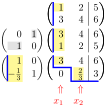

In [5]:
bundle = lf.ge_tbl_bundle(A, ref_rhs=rhs, pivoting="partial", show_pivots=True)
print(bundle.keys())
print(bundle["data"].keys())

tex = lf.ge_tbl_tex(A, ref_rhs=rhs, pivoting="partial")
svg = lf.ge_tbl_svg(A, ref_rhs=rhs, pivoting="partial")
display(SVG(svg))

## 4) Legacy-friendly GE stack wrapper

- `ge(matrices, ...)`: render from a precomputed matrix grid
- `show_ge(...)`: return display-ready object when possible


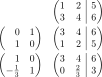

In [6]:
matrices = layers["matrices"]
svg2 = lf.ge(matrices, n_rhs=1)
display(SVG(svg2))